In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report

In [3]:
data = pd.read_csv('Absenteeism_at_work.csv', sep=';')

In [4]:
data.columns = data.columns.str.strip()

Data goes from July 2007 - July 2010

Total 36 months

In [5]:
data.head()

,ID,Reason for absence,Month of absence,Day of the week,Seasons,Transportation expense,Distance from Residence to Work,Service time,Age,Work load Average/day,...,Disciplinary failure,Education,Son,Social drinker,Social smoker,Pet,Weight,Height,Body mass index,Absenteeism time in hours
0,11,26,7,3,1,289,36,13,33,239.554,...,0,1,2,1,0,1,90,172,30,4
1,36,0,7,3,1,118,13,18,50,239.554,...,1,1,1,1,0,0,98,178,31,0
2,3,23,7,4,1,179,51,18,38,239.554,...,0,1,0,1,0,0,89,170,31,2
3,7,7,7,5,1,279,5,14,39,239.554,...,0,1,2,1,1,0,68,168,24,4
4,11,23,7,5,1,289,36,13,33,239.554,...,0,1,2,1,0,1,90,172,30,2


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   ID                               740 non-null    int64  
 1   Reason for absence               740 non-null    int64  
 2   Month of absence                 740 non-null    int64  
 3   Day of the week                  740 non-null    int64  
 4   Seasons                          740 non-null    int64  
 5   Transportation expense           740 non-null    int64  
 6   Distance from Residence to Work  740 non-null    int64  
 7   Service time                     740 non-null    int64  
 8   Age                              740 non-null    int64  
 9   Work load Average/day            740 non-null    float64
 10  Hit target                       740 non-null    int64  
 11  Disciplinary failure             740 non-null    int64  
 12  Education             

Total of 36 months included -> 52 * 3 = 156 weeks -> 156 * 40 = 6240 hours 

In [7]:
# aggregate by employee
emp = data.groupby("ID").agg(
    total_hrs_absences=("Absenteeism time in hours","sum"), # total absence hours throughout years
    total_disciplinary_failures=("Disciplinary failure","sum"), # total disciplinary failures throughout years
    avg_target=("Hit target", "mean"), # avg hit target throughout years
    avg_workload=("Work load Average/day","mean"), # avg workload/day throughout years
    avg_distance=("Distance from Residence to Work","mean") # avg distance from home to work throughout years
).reset_index()

emp.sort_values("total_hrs_absences", ascending=False)

,ID,total_hrs_absences,total_disciplinary_failures,avg_target,avg_workload,avg_distance
2,3,482,1,95.070796,262.175062,51.0
13,14,476,0,95.689655,299.354379,12.0
10,11,450,2,93.850000,271.434300,36.0
27,28,347,1,94.947368,282.104605,26.0
33,34,344,0,94.618182,270.551018,10.0
35,36,311,6,94.323529,272.283500,13.0
19,20,306,3,94.571429,267.201571,50.0
8,9,262,0,95.875000,249.042250,14.0
23,24,254,1,93.833333,278.970967,25.0
14,15,253,2,92.594595,280.316730,31.0


approx 6240 hours, consider hard working employees to miss < 1%  ->  62 days

In [8]:
# employees with low absences, low disciplinary failures and high target achievement
# can give them more work and they will do it
work_harder = emp[(emp["total_hrs_absences"] <= 62) & (emp['total_disciplinary_failures'] <= 2) & (emp["avg_target"] >= 96)].sort_values("avg_target", ascending=False)
work_harder

,ID,total_hrs_absences,total_disciplinary_failures,avg_target,avg_workload,avg_distance
15,16,16,0,97.500000,248.6425,15.0
28,29,21,1,97.200000,243.7386,17.2
30,31,16,1,96.666667,328.0180,15.0
11,12,34,0,96.142857,271.2740,51.0


Seems that employees 16, 31, 29, and 12 can be worked harder 


In [9]:
# other data for regression model
extra = data.groupby("ID").agg(
    age=("Age","mean"), # avg throughout the years
    bmi=("Body mass index","mean"), # avg throughout the years
    transport=("Transportation expense","mean"), # avg throughout the years
    edu=("Education","max"),   # max education attained, probably doesn't change throughout the years
    drink=("Social drinker","mean"),  # probably doesn't change, but accounts for just in case
    smoke=("Social smoker","mean"), # probably doesn't change, but accounts for just in case
    son=("Son","mean"), # avg throughout the years
    pet=("Pet","mean") # avg throughout the years
).reset_index()

emp = emp.merge(extra, on="ID", how="left")

In [10]:
# create chronic absentee column
emp['chronic_absentee'] = (emp['total_hrs_absences'] > 62).astype(int)

features = [
    "avg_target", "avg_workload", "avg_distance", "total_disciplinary_failures",
    "age", "bmi", "transport", "edu", "drink", "smoke", "son", "pet"
]
X = emp[features]
y = emp['chronic_absentee']

In [11]:
# split data and fit/transform with pipeline
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

lr_pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('model', LogisticRegression(random_state=42, class_weight='balanced', max_iter=5000))
])

lr_pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [15]:
pred_proba_test = lr_pipeline.predict_proba(X_test)[:, 0]  # probability of someone being a chronically absent employee
auc_test = roc_auc_score(y_test, pred_proba_test)

coef = pd.Series(
    lr_pipeline.named_steps['model'].coef_[0], 
    index=features
).sort_values(ascending=False)

print(f"AUC (test): {auc_test}")
print(coef)

AUC (test): 1.0
son                            1.071137
avg_distance                  -0.062965
drink                         -0.090146
total_disciplinary_failures   -0.104327
transport                     -0.291322
avg_workload                  -0.309366
bmi                           -0.333178
edu                           -0.423135
age                           -0.499655
smoke                         -0.657391
avg_target                    -0.812385
pet                           -0.822622
dtype: float64


We get a perfect AOC (1.0) BUT there are only 36 individuals in the dataset. Regression is overfitting here. In the real world, it would be necessary to use cross-validation and honestly to not use regression to make decisions for such a small dataset.  

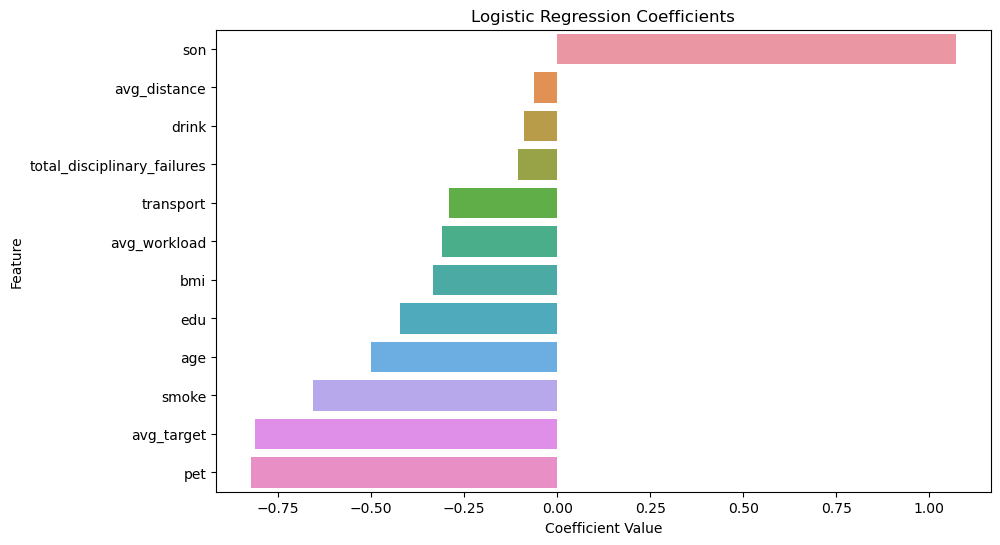

In [22]:
# Coefficient bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x=coef.values, y=coef.index)
plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()

Clearly having children is correlated with being chronically absent, so we should fire people with children. Having pets, having a high average target, and smoking are correlated with not being chronically absent, so we should not fire those people. 